In [1]:
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [2]:
import pandas as pd

df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Original shape:", df.shape)

df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Cleaned shape:", df.shape)
df.head()

Original shape: (541909, 8)
Cleaned shape: (397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
import datetime as dt

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

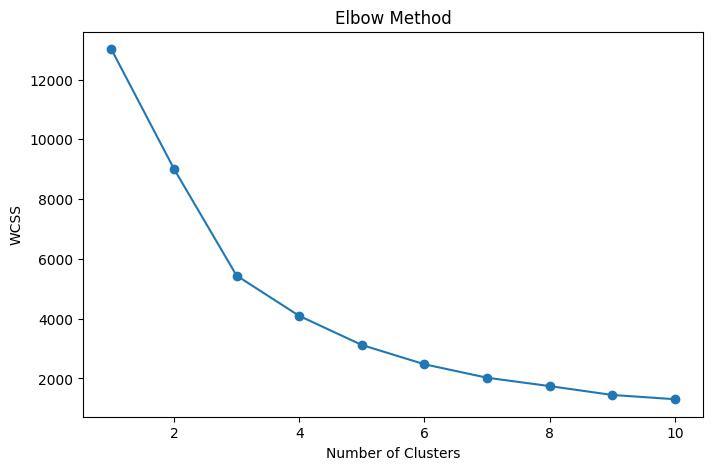

In [7]:
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_elbow.fit(rfm_scaled)
    wcss.append(kmeans_elbow.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm['Cluster'].value_counts()

,count
Cluster,
0,3054
1,1067
3,204
2,13


In [9]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)
cluster_summary['Count'] = rfm['Cluster'].value_counts()
cluster_summary

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,43.7,3.7,1359.0,3054
1,248.1,1.6,480.6,1067
2,7.4,82.5,127338.3,13
3,15.5,22.3,12709.1,204


In [10]:
cluster_labels = {
    0: 'Regular Customers',
    1: 'At-Risk / Lost',
    2: 'VIP / Champions',
    3: 'Loyal High-Value'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Loyal High-Value
12347.0,2,7,4310.00,0,Regular Customers
12348.0,75,4,1797.24,0,Regular Customers
12349.0,19,1,1757.55,0,Regular Customers
12350.0,310,1,334.40,1,At-Risk / Lost


In [11]:
segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)
segment_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk / Lost,248.08,1.55,480.62
Loyal High-Value,15.50,22.33,12709.09
Regular Customers,43.70,3.68,1359.05
VIP / Champions,7.38,82.54,127338.31


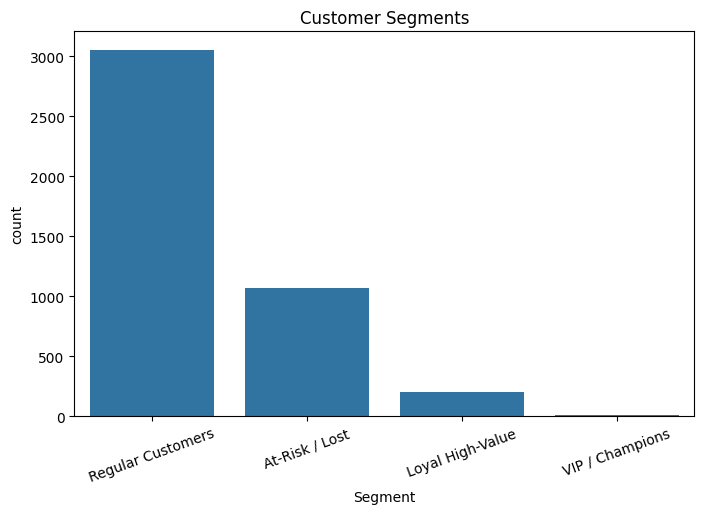

In [13]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=rfm, x="Segment", order=rfm["Segment"].value_counts().index)
plt.title("Customer Segments")
plt.xticks(rotation=20)
plt.show()

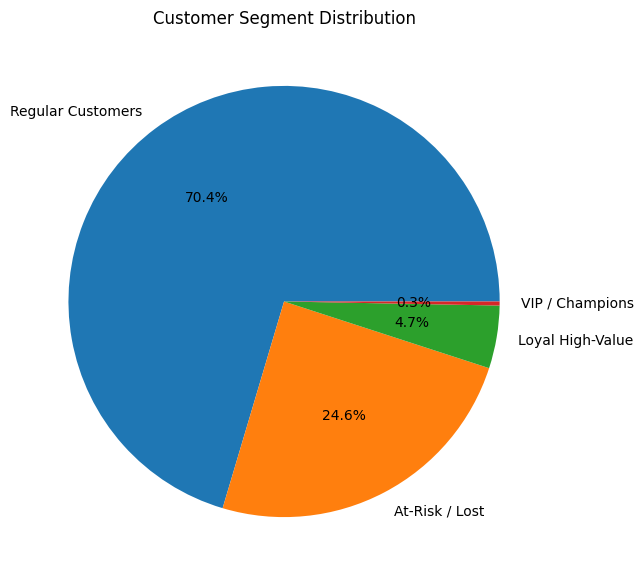

In [14]:
plt.figure(figsize=(7,7))
rfm["Segment"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()

In [15]:
top_customers = rfm.sort_values("Monetary", ascending=False).head(10)
top_customers

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
14646.0,2,73,280206.02,2,VIP / Champions
18102.0,1,60,259657.30,2,VIP / Champions
17450.0,8,46,194550.79,2,VIP / Champions
16446.0,1,2,168472.50,2,VIP / Champions
14911.0,1,201,143825.06,2,VIP / Champions
12415.0,24,21,124914.53,2,VIP / Champions
14156.0,10,55,117379.63,2,VIP / Champions
17511.0,3,31,91062.38,2,VIP / Champions
16029.0,39,63,81024.84,2,VIP / Champions


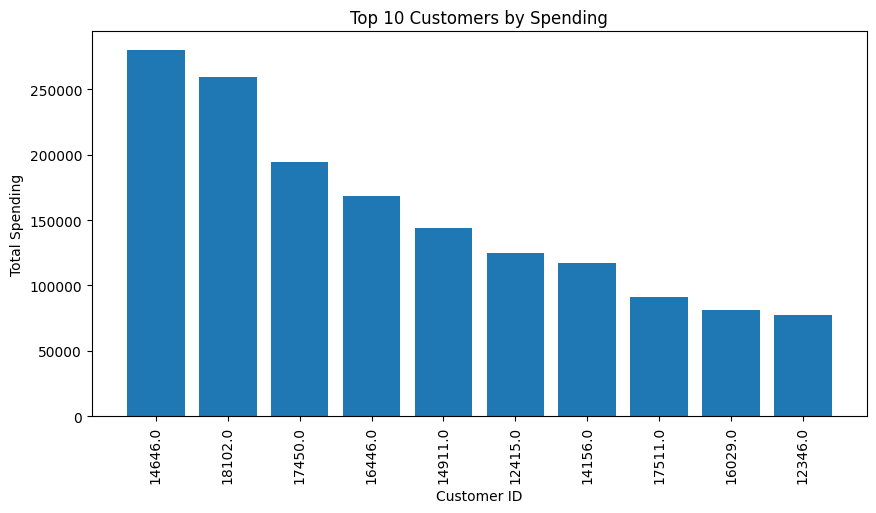

In [16]:
plt.figure(figsize=(10,5))
plt.bar(top_customers.index.astype(str), top_customers["Monetary"])
plt.xticks(rotation=90)
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

In [17]:
import numpy as np

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
months = sorted(df['InvoiceMonth'].unique())

monthly_rfm = []
for month in months:
    snapshot_date = month.to_timestamp() + pd.offsets.MonthEnd(1)
    data_till_now = df[df['InvoiceDate'] <= snapshot_date]
    if data_till_now.empty:
        continue
    temp_rfm = data_till_now.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'TotalPrice': 'sum'
    })
    temp_rfm.columns = ['Recency', 'Frequency', 'Monetary']
    temp_rfm['Month'] = str(month)
    monthly_rfm.append(temp_rfm)

monthly_rfm_df = pd.concat(monthly_rfm).reset_index()
monthly_rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,Month
0,12347.0,23,1,711.79,2010-12
1,12348.0,14,1,892.80,2010-12
2,12370.0,13,2,1868.02,2010-12
3,12377.0,10,1,1001.52,2010-12
4,12383.0,8,1,600.72,2010-12


In [18]:
scaler2 = StandardScaler()
monthly_scaled = scaler2.fit_transform(monthly_rfm_df[['Recency', 'Frequency', 'Monetary']])

kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
monthly_rfm_df['Cluster'] = kmeans2.fit_predict(monthly_scaled)

monthly_cluster_summary = monthly_rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)
monthly_cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.6,2.9,1102.8
1,21.3,22.9,15222.3
2,205.0,1.5,464.4
3,12.6,68.2,122980.0


In [19]:
monthly_cluster_labels = {
    0: 'Regular Customers',
    1: 'Loyal High-Value',
    2: 'At-Risk / Lost',
    3: 'VIP / Champions'
}
monthly_rfm_df['Segment'] = monthly_rfm_df['Cluster'].map(monthly_cluster_labels)
monthly_rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,Month,Cluster,Segment
0,12347.0,23,1,711.79,2010-12,0,Regular Customers
1,12348.0,14,1,892.80,2010-12,0,Regular Customers
2,12370.0,13,2,1868.02,2010-12,0,Regular Customers
3,12377.0,10,1,1001.52,2010-12,0,Regular Customers
4,12383.0,8,1,600.72,2010-12,0,Regular Customers


In [20]:
import plotly.express as px

fig = px.scatter(
    monthly_rfm_df,
    x="Recency",
    y="Monetary",
    animation_frame="Month",
    animation_group="CustomerID",
    size="Frequency",
    color="Segment",
    hover_name="CustomerID",
    log_y=True,
    size_max=45,
    range_x=[0, monthly_rfm_df['Recency'].max()+10],
    title="Customer Segmentation Over Time (RFM Analysis)",
    labels={"Recency": "Recency (days since last purchase)", "Monetary": "Total Spend (₹, log scale)"}
)
fig.update_layout(height=600, legend_title_text='Customer Segment')
fig.show()

In [21]:
fig3d = px.scatter_3d(
    rfm,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color="Segment",
    hover_name=rfm.index.astype(str),
    title="3D Customer Segmentation"
)
fig3d.show()